<a href="https://colab.research.google.com/github/baynobu/pembelajaran-mesin-26/blob/main/TG4_244107020232_Abdul_Rahman_Hanif_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('/content/drive/MyDrive/Uni/Internal/Semester 5/Pembelajaran Mesin/Dataset/Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

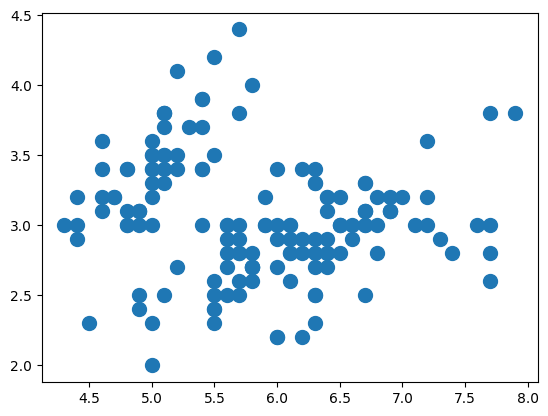

In [3]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [4]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

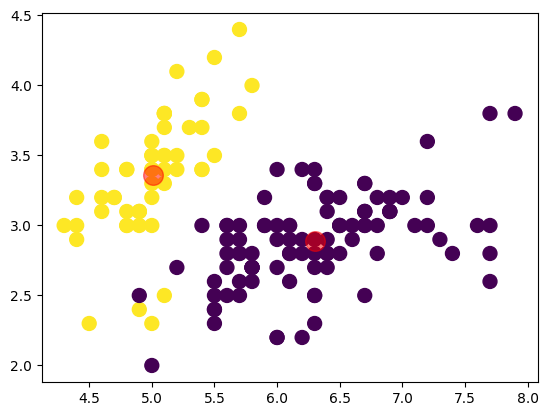

In [5]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [6]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


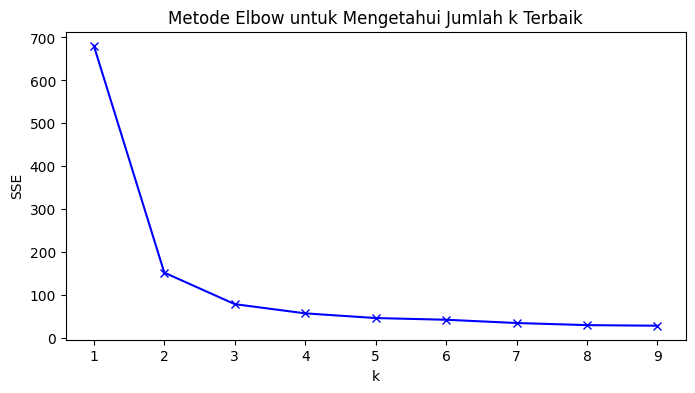

In [8]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [9]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94084142614601
k=4; SSE=57.4732732654949
k=5; SSE=46.55057267267267
k=6; SSE=42.56646318681319
k=7; SSE=34.992318953736344
k=8; SSE=30.083825236167346
k=9; SSE=28.681678904428914


# Praktikum 2

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

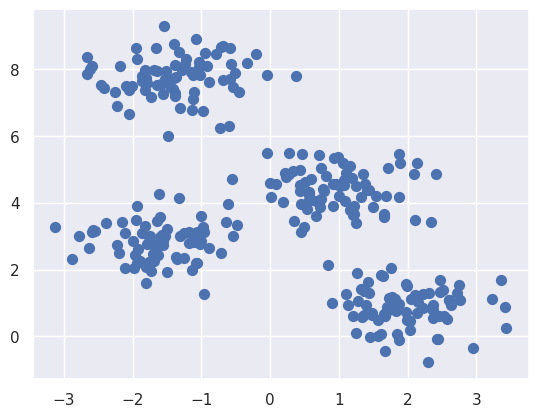

In [11]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [12]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

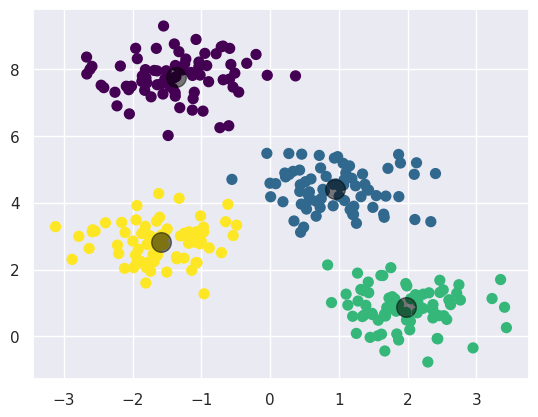

In [13]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

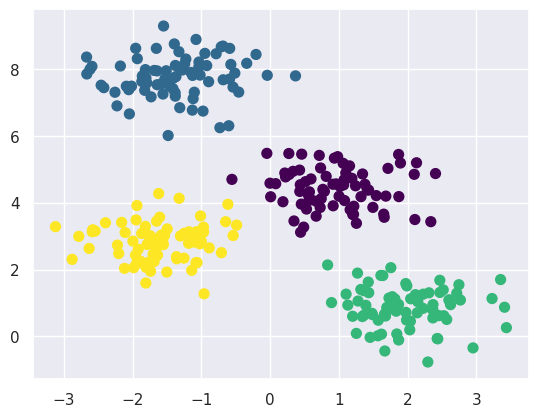

In [14]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

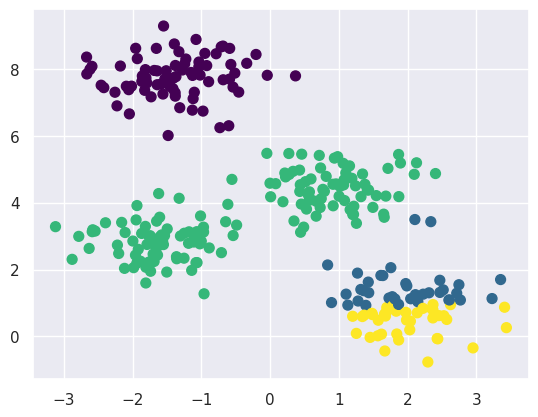

In [15]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

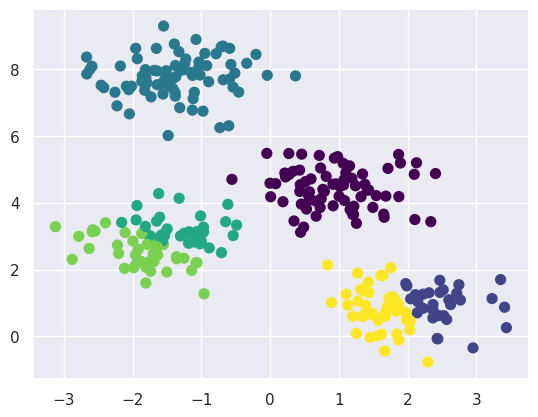

In [16]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

In [17]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

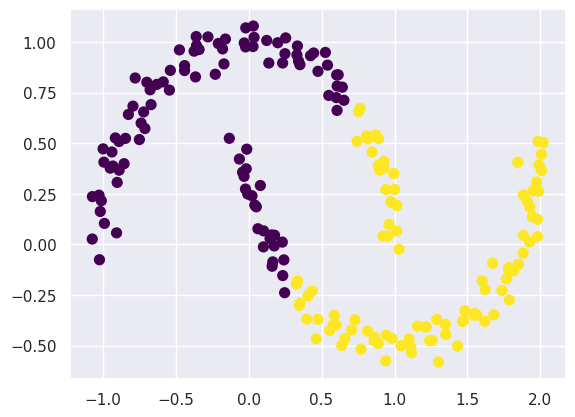

In [18]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


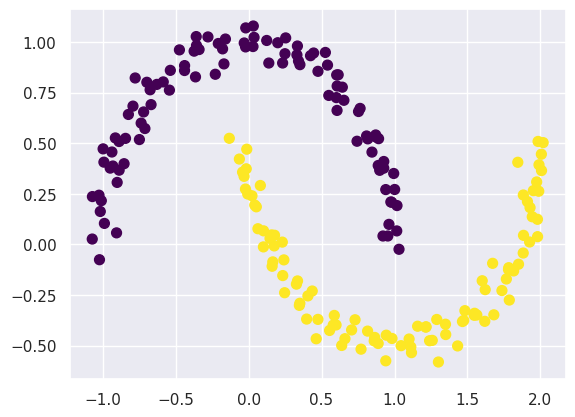

In [19]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

# Contoh Kasus 1: Karakter Angka

In [20]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [21]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

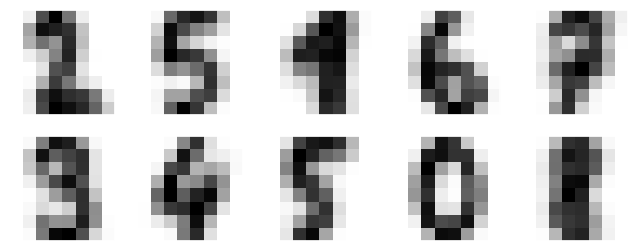

In [22]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [23]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [24]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

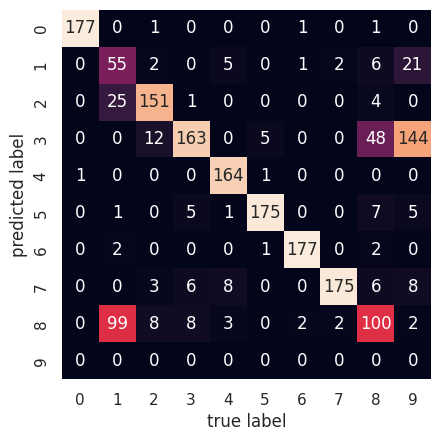

In [25]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [26]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

# Studi Kasus 2: Kompresi Citra

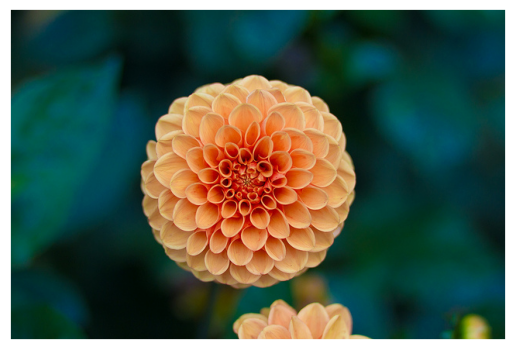

In [28]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [29]:
flower.shape

(427, 640, 3)

In [30]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [31]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

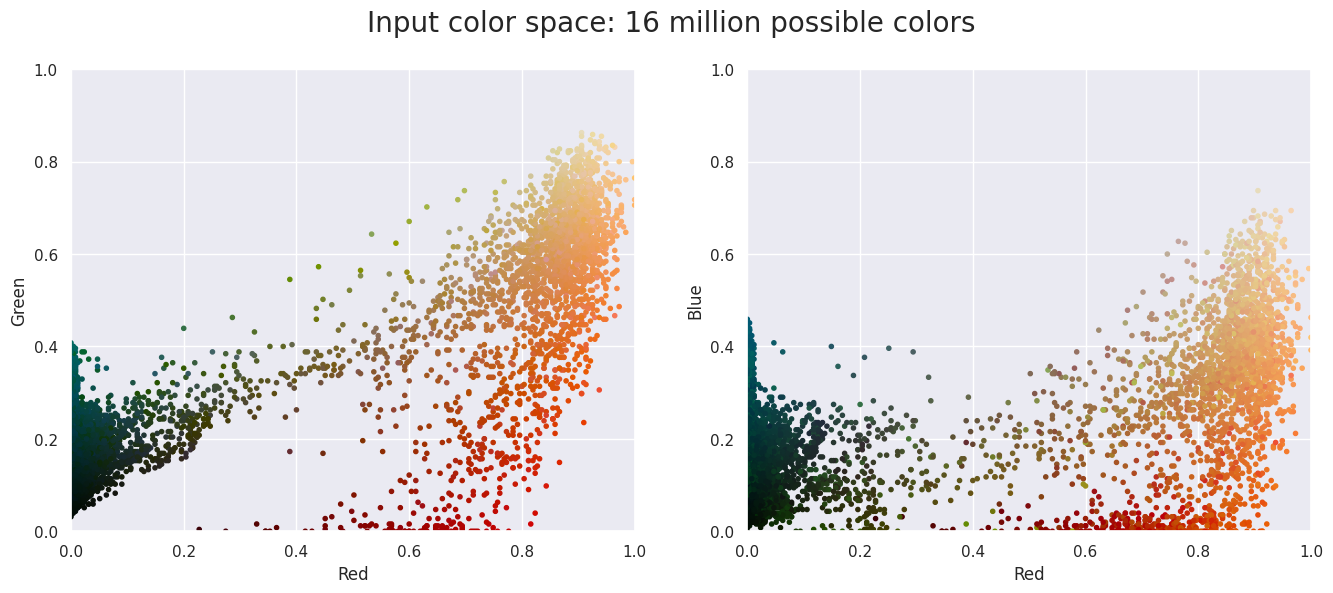

In [32]:
plot_pixels(data, title='Input color space: 16 million possible colors')

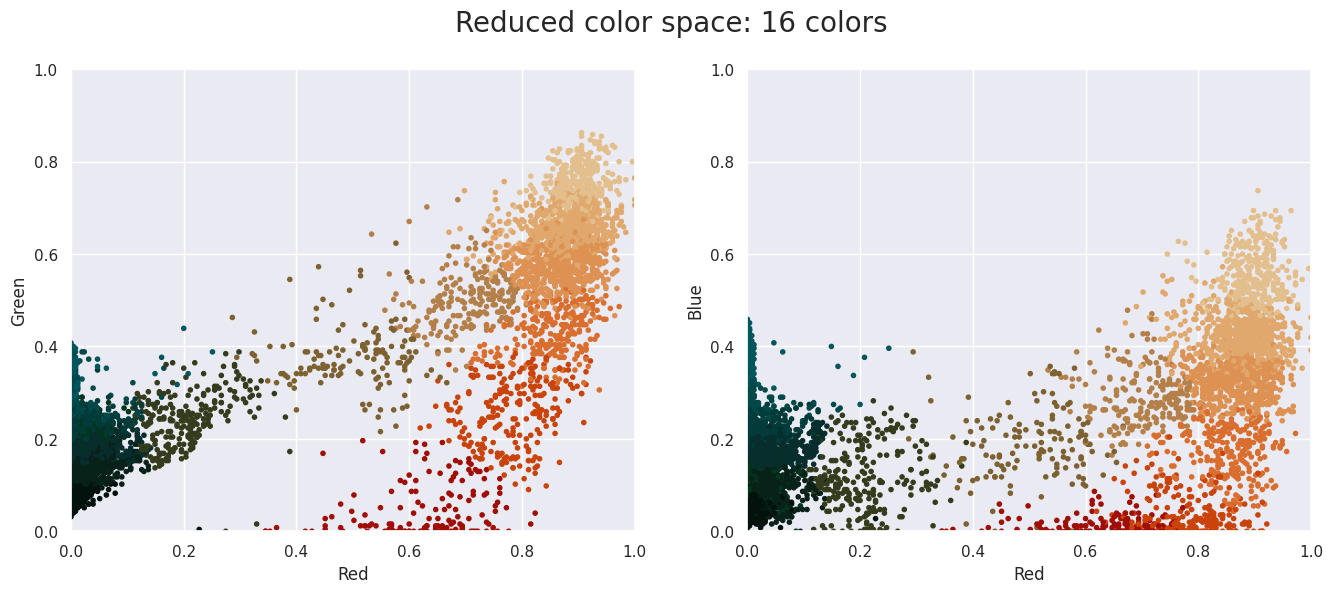

In [33]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

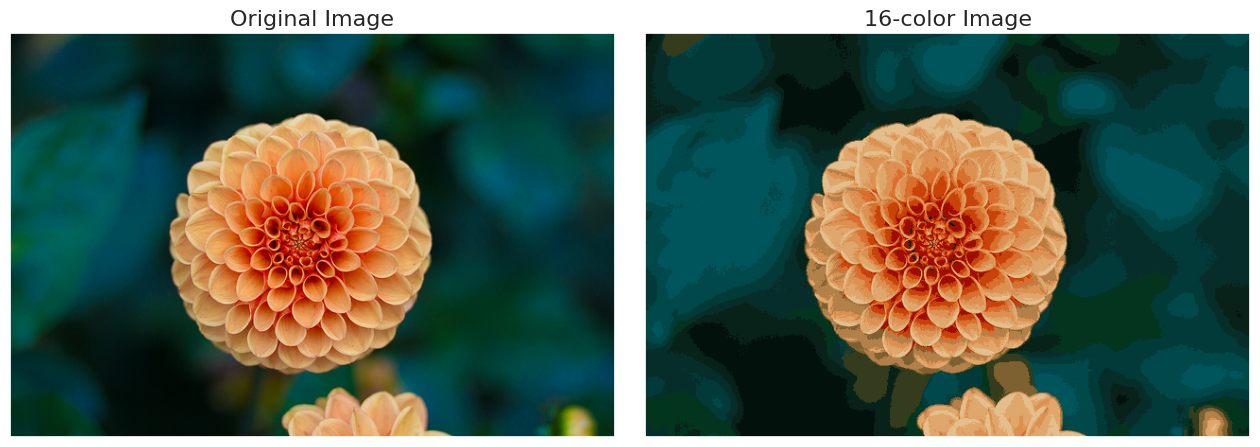

In [34]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

# Praktikum 3

In [36]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

In [37]:
import matplotlib.pyplot as plt

(X[:, 0], X[:, 1])
()

()

In [40]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


In [42]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


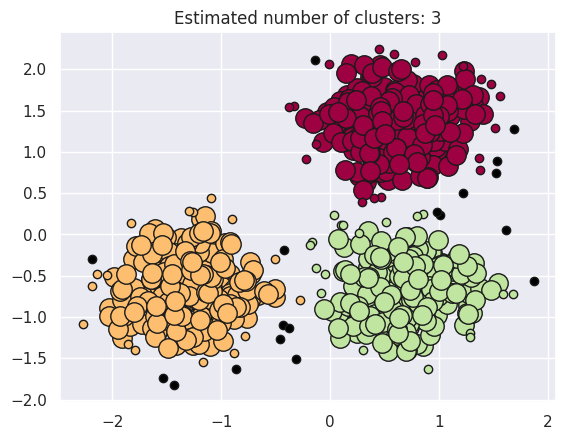

In [44]:
import matplotlib.pyplot as plt
import numpy as np

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Hitam untuk titik noise
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    # Plot core samples (titik lebih besar)
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    # Plot non-core samples (titik lebih kecil)
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

# Tugas Praktikum

### Tugas K-Means

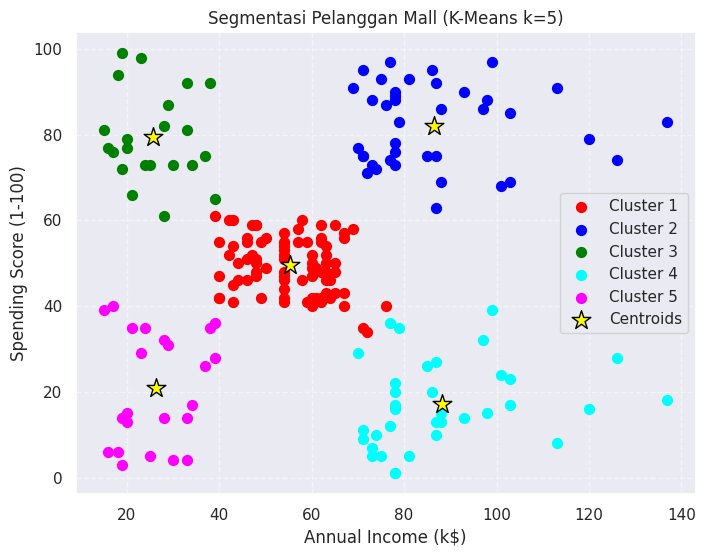

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Membaca dataset
df_mall = pd.read_csv('/content/drive/MyDrive/Uni/Internal/Semester 5/Pembelajaran Mesin/Dataset/Mall_Customers.csv')

# 2. Memilih fitur
X_mall = df_mall[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Menentukan k terbaik dengan Elbow Method & Silhouette Score
wcss = []
silhouette_vals = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_mall)
    wcss.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_mall, km.labels_))

# 3. Melatih model K-Means dengan k=5
kmeans_opt = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans_opt.fit_predict(X_mall)

# Visualisasi Hasil Segmentasi
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
cluster_names = ['Sensible', 'Standard', 'Target', 'Careless', 'Careful']

for i in range(5):
    plt.scatter(X_mall[y_kmeans == i, 0], X_mall[y_kmeans == i, 1],
                s=50, c=colors[i], label=f'Cluster {i+1}')

plt.scatter(kmeans_opt.cluster_centers_[:, 0], kmeans_opt.cluster_centers_[:, 1],
            s=200, c='yellow', marker='*', edgecolor='black', label='Centroids')
plt.title('Segmentasi Pelanggan Mall (K-Means k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Tugas DBSCAN

Jumlah klaster terestimasi: 2
Jumlah noise points      : 0

--- Metrik Evaluasi ---
Homogeneity            : 1.0000
Completeness           : 1.0000
V-measure              : 1.0000
Adjusted Rand Index    : 1.0000
Adjusted Mutual Info   : 1.0000
Silhouette Coefficient : 0.3912


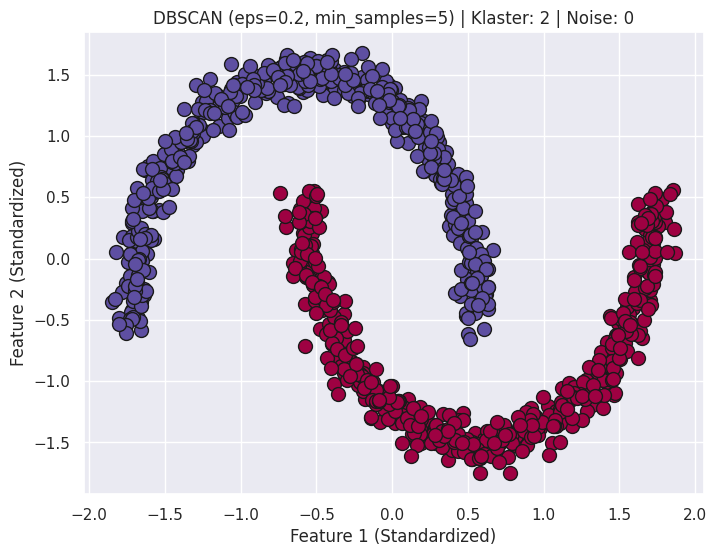

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 1. Buat dataset make_moons dan normalisasi
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_scaled = StandardScaler().fit_transform(X_moons)

# 2. Jalankan DBSCAN (eps=0.2, min_samples=5)
db = DBSCAN(eps=0.2, min_samples=5).fit(X_scaled)
labels = db.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Jumlah klaster terestimasi: {n_clusters}")
print(f"Jumlah noise points      : {n_noise}")

# 3. Evaluasi Metrik
print("\n--- Metrik Evaluasi ---")
print(f"Homogeneity            : {metrics.homogeneity_score(y_moons, labels):.4f}")
print(f"Completeness           : {metrics.completeness_score(y_moons, labels):.4f}")
print(f"V-measure              : {metrics.v_measure_score(y_moons, labels):.4f}")
print(f"Adjusted Rand Index    : {metrics.adjusted_rand_score(y_moons, labels):.4f}")
print(f"Adjusted Mutual Info   : {metrics.adjusted_mutual_info_score(y_moons, labels):.4f}")
print(f"Silhouette Coefficient : {metrics.silhouette_score(X_scaled, labels):.4f}")

# 4. Visualisasi Hasil DBSCAN
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Hitam untuk noise

    class_member_mask = labels == k

    # Core samples (titik besar)
    xy_core = X_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy_core[:, 0], xy_core[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=10, label=f'Cluster {k} (Core)' if k != -1 else 'Noise')

    # Non-core samples (titik kecil)
    xy_non_core = X_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy_non_core[:, 0], xy_non_core[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=5)

plt.title(f"DBSCAN (eps=0.2, min_samples=5) | Klaster: {n_clusters} | Noise: {n_noise}")
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.show()

In [48]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 1. Siapkan dataset make_moons dan normalisasi
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_scaled = StandardScaler().fit_transform(X_moons)

# 2. Definisikan kombinasi parameter eksperimen
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

results = []

# 3. Looping untuk menguji setiap kombinasi parameter
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms).fit(X_scaled)
        labels = db.labels_

        # Hitung jumlah klaster (abaikan label -1/noise) dan jumlah noise
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Hitung metrik evaluasi eksternal
        homo = metrics.homogeneity_score(y_moons, labels)
        comp = metrics.completeness_score(y_moons, labels)
        v_meas = metrics.v_measure_score(y_moons, labels)
        ari = metrics.adjusted_rand_score(y_moons, labels)
        ami = metrics.adjusted_mutual_info_score(y_moons, labels)

        # Silhouette score hanya bisa dihitung jika terdapat minimal 2 klaster
        # dan tidak seluruh titik menjadi klaster individual tersendiri
        if n_clusters > 1 and len(set(labels)) < len(labels):
            sil = metrics.silhouette_score(X_scaled, labels)
        else:
            sil = np.nan

        results.append({
            'eps': eps,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'Homogeneity': round(homo, 4),
            'Completeness': round(comp, 4),
            'V-measure': round(v_meas, 4),
            'ARI': round(ari, 4),
            'AMI': round(ami, 4),
            'Silhouette': round(sil, 4) if not np.isnan(sil) else None
        })

# 4. Tampilkan hasil eksperimen dalam bentuk DataFrame
df_experiments = pd.DataFrame(results)
display(df_experiments)

,eps,min_samples,n_clusters,n_noise,Homogeneity,Completeness,V-measure,ARI,AMI,Silhouette
0,0.05,3,69,186,0.8156,0.1525,0.2570,0.0300,0.2438,0.1129
1,0.05,10,3,970,0.0307,0.1268,0.0494,0.0023,0.0459,-0.2942
2,0.05,20,0,1000,0.0000,1.0000,0.0000,0.0000,0.0000,NaN
3,0.10,3,2,14,0.9862,0.9029,0.9427,0.9722,0.9426,0.2517
4,0.10,10,7,57,0.9433,0.4095,0.5711,0.5234,0.5698,0.1623
5,0.10,20,6,850,0.1539,0.1555,0.1547,0.0168,0.1509,-0.3602
6,0.30,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
7,0.30,10,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
8,0.30,20,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
9,0.50,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912


# Kesimpulan Eksperimen

1. Pengaruh eps: Jika eps terlalu kecil ($\le 0.05$), algoritma sangat sensitif terhadap celah antar-titik sehingga menghasilkan jumlah klaster berlebih (over-clustering) atau menganggap hampir semua titik sebagai noise. Nilai eps $\ge 0.2$ sangat ideal untuk menghubungkan pola kurva non-linier pada make_moons.

2. Pengaruh min_samples: Semakin tinggi nilai min_samples, semakin ketat syarat suatu titik untuk menjadi core point. Pada eps kecil, menaikkan min_samples menyebabkan lonjakan drastis pada jumlah data yang dicap sebagai noise.

3. Kualitas Evaluasi: Nilai ARI dan V-Measure mencapai skor sempurna ($1.0$) pada rentang eps $0.2 - 0.5$, membuktikan keunggulan algoritma berbasis densitas (DBSCAN) dalam memodelkan struktur data non-spherical dibandingkan K-Means.